In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_excel('online_course_recommendation.xlsx', sheet_name='Sheet1')
print(f"Dataset Shape: {df.shape}")
print(df.head())

Dataset Shape: (100000, 14)
   user_id  course_id                       course_name       instructor  \
0    15796       9366              Python for Beginners      Emma Harris   
1      861       1928   Cybersecurity for Professionals  Alexander Young   
2    38159       9541  DevOps and Continuous Deployment   Dr. Mia Walker   
3    44733       3708   Project Management Fundamentals   Benjamin Lewis   
4    11285       3361       Ethical Hacking Masterclass     Daniel White   

   course_duration_hours certification_offered difficulty_level  rating  \
0                   39.1                   Yes         Beginner     5.0   
1                   36.3                   Yes         Beginner     4.3   
2                   13.4                   Yes         Beginner     3.9   
3                   58.3                   Yes         Beginner     3.1   
4                   30.8                   Yes         Beginner     2.8   

   enrollment_numbers  course_price  feedback_score study_materi

In [2]:
df.head()

,user_id,course_id,course_name,instructor,course_duration_hours,certification_offered,difficulty_level,rating,enrollment_numbers,course_price,feedback_score,study_material_available,time_spent_hours,previous_courses_taken
0,15796,9366,Python for Beginners,Emma Harris,39.1,Yes,Beginner,5.0,21600,317.50,0.797,Yes,17.60,4
1,861,1928,Cybersecurity for Professionals,Alexander Young,36.3,Yes,Beginner,4.3,15379,40.99,0.770,Yes,28.97,9
2,38159,9541,DevOps and Continuous Deployment,Dr. Mia Walker,13.4,Yes,Beginner,3.9,6431,380.81,0.772,Yes,52.44,4
3,44733,3708,Project Management Fundamentals,Benjamin Lewis,58.3,Yes,Beginner,3.1,48245,342.80,0.969,No,22.29,6
4,11285,3361,Ethical Hacking Masterclass,Daniel White,30.8,Yes,Beginner,2.8,34556,381.01,0.555,Yes,22.01,5


In [3]:
# Basic info
print("\n=== Dataset Info ===")
print(df.info())
print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Descriptive Statistics ===")
print(df.describe())

# Unique counts
print("\n=== Unique Values ===")
print(f"Unique Users: {df['user_id'].nunique()}")
print(f"Unique Courses (by course_id): {df['course_id'].nunique()}")
print(f"Unique Course Names: {df['course_name'].nunique()}")
print(f"Unique Instructors: {df['instructor'].nunique()}")


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   user_id                   100000 non-null  int64  
 1   course_id                 100000 non-null  int64  
 2   course_name               100000 non-null  object 
 3   instructor                100000 non-null  object 
 4   course_duration_hours     100000 non-null  float64
 5   certification_offered     100000 non-null  object 
 6   difficulty_level          100000 non-null  object 
 7   rating                    100000 non-null  float64
 8   enrollment_numbers        100000 non-null  int64  
 9   course_price              100000 non-null  float64
 10  feedback_score            100000 non-null  float64
 11  study_material_available  100000 non-null  object 
 12  time_spent_hours          100000 non-null  float64
 13  previous_courses_taken 

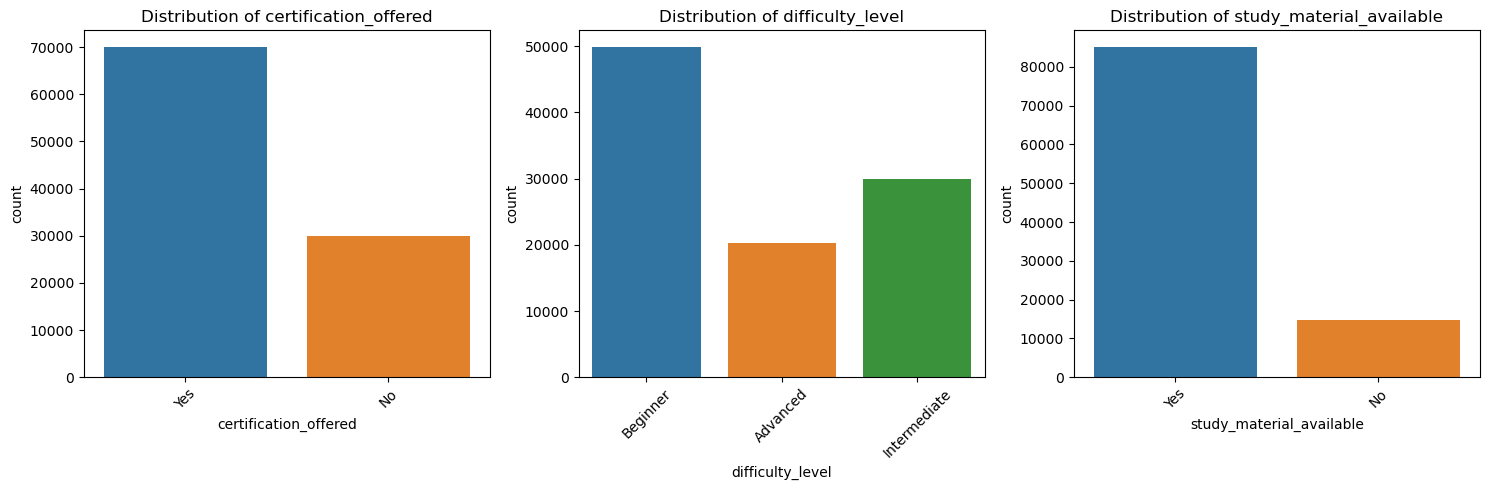

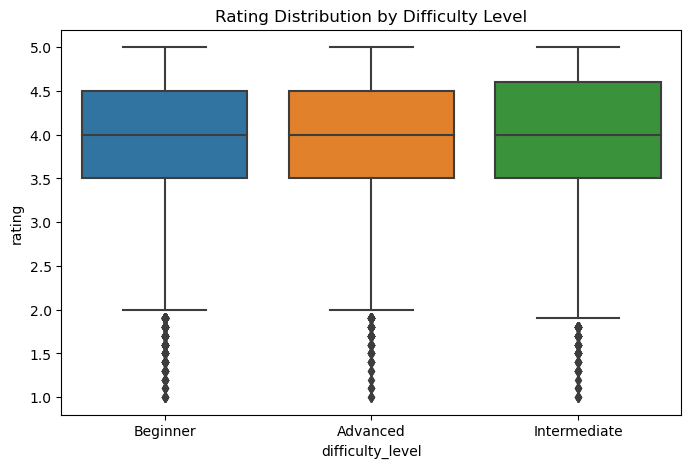

In [4]:
# Categorical distributions
cat_cols = ['certification_offered', 'difficulty_level', 'study_material_available']

plt.figure(figsize=(15, 5))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(1, 3, i)
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Rating by difficulty
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='difficulty_level', y='rating')
plt.title('Rating Distribution by Difficulty Level')
plt.show()

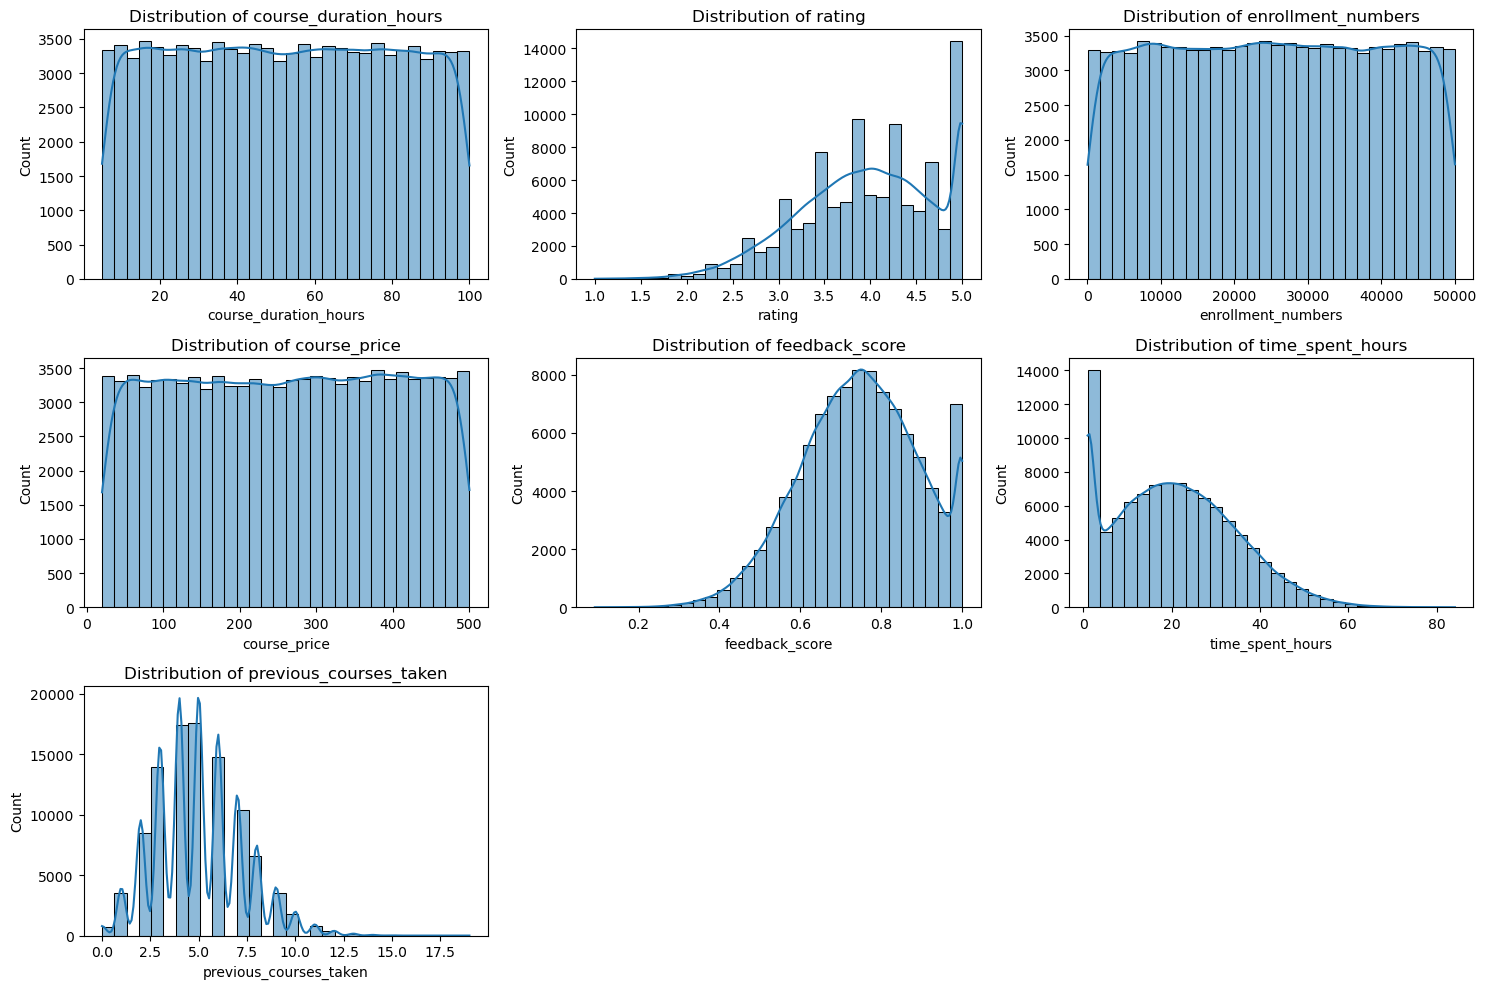

In [5]:
num_cols = ['course_duration_hours', 'rating', 'enrollment_numbers',
            'course_price', 'feedback_score', 'time_spent_hours', 'previous_courses_taken']

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

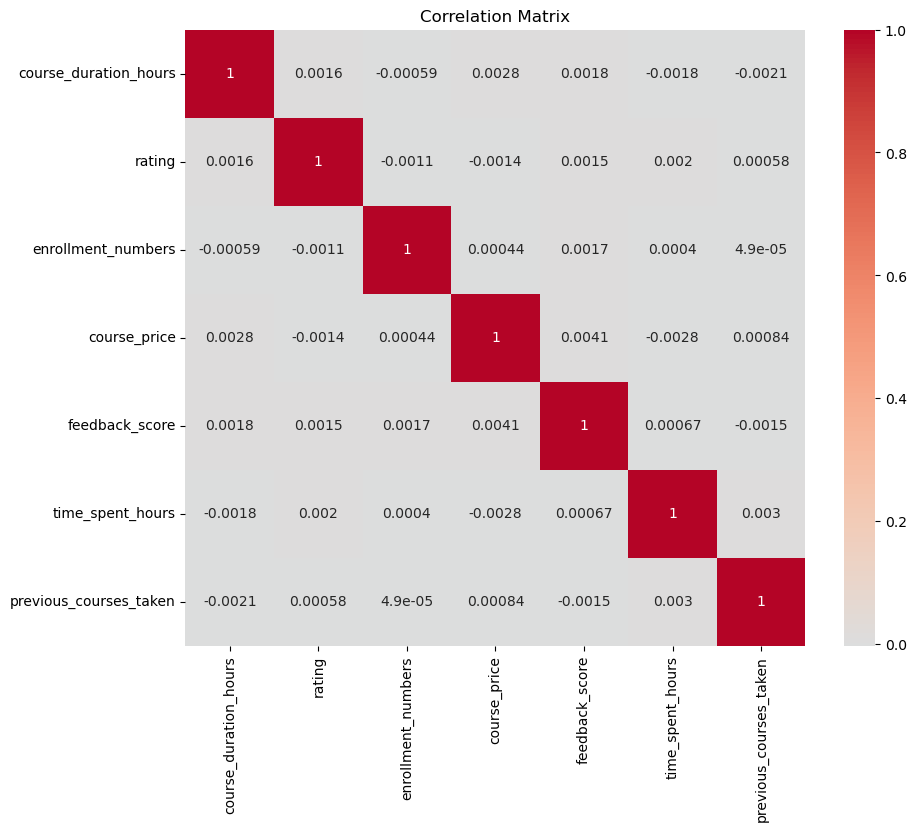

In [6]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm',center=0)
plt.title('Correlation Matrix')
plt.show()

In [7]:
# Top 10 courses by enrollment
top_courses = df.groupby('course_name')['enrollment_numbers'].mean().sort_values(ascending=False).head(10)
print("\nTop 10 Courses by Average Enrollment:")
print(top_courses)

# Average rating by course
course_ratings = df.groupby('course_name')['rating'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print("\nTop Rated Courses:")
print(course_ratings.head(20))


Top 10 Courses by Average Enrollment:
course_name
Graphic Design with Canva                    25356.299980
Fitness and Nutrition Coaching               25334.165205
Blockchain and Decentralized Applications    25313.235519
DevOps and Continuous Deployment             25241.720469
Cloud Computing Essentials                   25154.256801
AI for Business Leaders                      25131.299581
Ethical Hacking Masterclass                  25094.782102
Photography and Video Editing                25080.566166
Cybersecurity for Professionals              25056.595116
Fundamentals of Digital Marketing            25032.141994
Name: enrollment_numbers, dtype: float64

Top Rated Courses:
                                               mean  count
course_name                                               
Python for Beginners                       3.977652   4931
Cloud Computing Essentials                 3.974624   4926
Photography and Video Editing              3.970811   4995
Advanced Mach

In [8]:
# User engagement
user_stats = df.groupby('user_id').agg({
    'course_id': 'count',
    'time_spent_hours': 'sum',
    'previous_courses_taken': 'mean',
    'rating': 'mean'
}).rename(columns={'course_id': 'courses_taken'})

print("\nUser Statistics Summary:")
print(user_stats.describe())


User Statistics Summary:
       courses_taken  time_spent_hours  previous_courses_taken        rating
count   43242.000000      43242.000000            43242.000000  43242.000000
mean        2.312566         47.849439                4.995168      3.961209
std         1.254923         33.296006                1.699229      0.554016
min         1.000000          1.000000                0.000000      1.000000
25%         1.000000         23.050000                4.000000      3.620000
50%         2.000000         41.550000                5.000000      4.000000
75%         3.000000         66.367500                6.000000      4.333333
max        11.000000        253.130000               16.000000      5.000000


In [9]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Copy for preprocessing
df_prep = df.copy()

# 1. Encode Categorical Variables
le_dict = {}
for col in ['certification_offered', 'difficulty_level', 'study_material_available']:
    le = LabelEncoder()
    df_prep[col] = le.fit_transform(df_prep[col])
    le_dict[col] = le
    print(f"Encoded {col}: {le.classes_}")

# 2. Feature Engineering
df_prep['price_per_hour'] = df_prep['course_price'] / df_prep['course_duration_hours']
df_prep['engagement_score'] = df_prep['time_spent_hours'] / df_prep['course_duration_hours']
df_prep['rating_feedback'] = df_prep['rating'] * df_prep['feedback_score']

# 3. Handle any potential outliers
def cap_outliers(series, lower=0.01, upper=0.99):
    lower_bound = series.quantile(lower)
    upper_bound = series.quantile(upper)
    return series.clip(lower_bound, upper_bound)

for col in ['time_spent_hours', 'enrollment_numbers', 'course_price']:
    df_prep[col] = cap_outliers(df_prep[col])

# 4. Scaling Numerical Features
scaler = StandardScaler()
num_features = ['course_duration_hours', 'rating', 'enrollment_numbers',
                'course_price', 'feedback_score', 'time_spent_hours',
                'previous_courses_taken', 'price_per_hour', 'engagement_score']

df_prep[num_features] = scaler.fit_transform(df_prep[num_features])

print("\nPreprocessing completed!")
print(df_prep.head())

Encoded certification_offered: ['No' 'Yes']
Encoded difficulty_level: ['Advanced' 'Beginner' 'Intermediate']
Encoded study_material_available: ['No' 'Yes']

Preprocessing completed!
   user_id  course_id                       course_name       instructor  \
0    15796       9366              Python for Beginners      Emma Harris   
1      861       1928   Cybersecurity for Professionals  Alexander Young   
2    38159       9541  DevOps and Continuous Deployment   Dr. Mia Walker   
3    44733       3708   Project Management Fundamentals   Benjamin Lewis   
4    11285       3361       Ethical Hacking Masterclass     Daniel White   

   course_duration_hours  certification_offered  difficulty_level    rating  \
0              -0.484388                      1                 1  1.424941   
1              -0.586491                      1                 1  0.465976   
2              -1.421546                      1                 1 -0.082004   
3               0.215745                     

In [10]:
# Save preprocessed data
df_prep.to_csv('preprocessed_courses.csv', index=False)
print("Preprocessed data saved as 'preprocessed_courses.csv'")

Preprocessed data saved as 'preprocessed_courses.csv'
